# PART 5: Regression Analysis

## Multiple Regression

### The Movie Dataset - Preparing the Data

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
movie = pd.read_csv("movies_metadata.csv", low_memory= False)

In [3]:
movie.head()

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,release_date,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
0,False,"{'id': 10194, 'name': 'Toy Story Collection', ...",30000000,"[{'id': 16, 'name': 'Animation'}, {'id': 35, '...",http://toystory.disney.com/toy-story,862,tt0114709,en,Toy Story,"Led by Woody, Andy's toys live happily in his ...",...,1995-10-30,373554033.0,81.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,Toy Story,False,7.7,5415.0
1,False,NaN,65000000,"[{'id': 12, 'name': 'Adventure'}, {'id': 14, '...",NaN,8844,tt0113497,en,Jumanji,When siblings Judy and Peter discover an encha...,...,1995-12-15,262797249.0,104.0,"[{'iso_639_1': 'en', 'name': 'English'}, {'iso...",Released,Roll the dice and unleash the excitement!,Jumanji,False,6.9,2413.0
2,False,"{'id': 119050, 'name': 'Grumpy Old Men Collect...",0,"[{'id': 10749, 'name': 'Romance'}, {'id': 35, ...",NaN,15602,tt0113228,en,Grumpier Old Men,A family wedding reignites the ancient feud be...,...,1995-12-22,0.0,101.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Still Yelling. Still Fighting. Still Ready for...,Grumpier Old Men,False,6.5,92.0
3,False,NaN,16000000,"[{'id': 35, 'name': 'Comedy'}, {'id': 18, 'nam...",NaN,31357,tt0114885,en,Waiting to Exhale,"Cheated on, mistreated and stepped on, the wom...",...,1995-12-22,81452156.0,127.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Friends are the people who let you be yourself...,Waiting to Exhale,False,6.1,34.0
4,False,"{'id': 96871, 'name': 'Father of the Bride Col...",0,"[{'id': 35, 'name': 'Comedy'}]",NaN,11862,tt0113041,en,Father of the Bride Part II,Just when George Banks has recovered from his ...,...,1995-02-10,76578911.0,106.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,Just When His World Is Back To Normal... He's ...,Father of the Bride Part II,False,5.7,173.0


In [4]:
movie.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45466 entries, 0 to 45465
Data columns (total 24 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   adult                  45466 non-null  object 
 1   belongs_to_collection  4494 non-null   object 
 2   budget                 45466 non-null  object 
 3   genres                 45466 non-null  object 
 4   homepage               7782 non-null   object 
 5   id                     45466 non-null  object 
 6   imdb_id                45449 non-null  object 
 7   original_language      45455 non-null  object 
 8   original_title         45466 non-null  object 
 9   overview               44512 non-null  object 
 10  popularity             45461 non-null  object 
 11  poster_path            45080 non-null  object 
 12  production_companies   45463 non-null  object 
 13  production_countries   45463 non-null  object 
 14  release_date           45379 non-null  object 
 15  re

In [5]:
movie = movie.set_index(pd.to_datetime(movie.release_date, errors = "coerce")).drop(columns = ["release_date"])

In [6]:
movie.sort_index(inplace = True)
movie

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,production_countries,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
release_date,,,,,,,,,,,,,,,,,,,,,
1874-12-09,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,315946,tt3155794,xx,Passage de Venus,Photo sequence of the rare transit of Venus ov...,...,"[{'iso_3166_1': 'FR', 'name': 'France'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Passage of Venus,False,6.0,19.0
1878-06-14,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,194079,tt2221420,en,Sallie Gardner at a Gallop,Sallie Gardner at a Gallop was one of the earl...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Sallie Gardner at a Gallop,False,6.2,25.0
1883-11-19,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,426903,tt5459794,en,Buffalo Running,Individual photographs of the running of a buf...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Buffalo Running,False,5.4,7.0
1887-08-18,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,159897,tt2075247,xx,Man Walking Around a Corner,The last remaining production of Le Prince's L...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Man Walking Around a Corner,False,4.1,17.0
1888-01-01,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,96882,tt1758563,xx,Accordion Player,The last remaining film of Le Prince's LPCCP T...,...,"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Accordion Player,False,4.4,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NaT,False,NaN,0,[],NaN,438910,tt0810384,ru,Konstruktor krasnogo tsveta -1993,Engineering Red - 1993 Dir: Andrey I. Y. Petr...,...,[],0.0,76.0,[],Released,NaN,Engineering Red,False,6.0,2.0
NaT,False,NaN,0,"[{'id': 9648, 'name': 'Mystery'}, {'id': 878, ...",NaN,433711,tt3158690,en,All Superheroes Must Die 2: The Last Superhero,"In a no holds barred documentary, acclaimed jo...",...,[],0.0,74.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Released,NaN,All Superheroes Must Die 2: The Last Superhero,False,4.0,1.0
NaT,False,NaN,0,[],NaN,335251,tt1883368,en,The Land Where the Blues Began,An exploration of the musical and social origi...,...,[],0.0,0.0,[],Released,NaN,The Land Where the Blues Began,False,0.0,0.0


In [7]:
# Remove rows with NaT in the index
movie = movie[~movie.index.isna()]
movie

,adult,belongs_to_collection,budget,genres,homepage,id,imdb_id,original_language,original_title,overview,...,production_countries,revenue,runtime,spoken_languages,status,tagline,title,video,vote_average,vote_count
release_date,,,,,,,,,,,,,,,,,,,,,
1874-12-09,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,315946,tt3155794,xx,Passage de Venus,Photo sequence of the rare transit of Venus ov...,...,"[{'iso_3166_1': 'FR', 'name': 'France'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Passage of Venus,False,6.0,19.0
1878-06-14,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,194079,tt2221420,en,Sallie Gardner at a Gallop,Sallie Gardner at a Gallop was one of the earl...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Sallie Gardner at a Gallop,False,6.2,25.0
1883-11-19,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,426903,tt5459794,en,Buffalo Running,Individual photographs of the running of a buf...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Buffalo Running,False,5.4,7.0
1887-08-18,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,159897,tt2075247,xx,Man Walking Around a Corner,The last remaining production of Le Prince's L...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Man Walking Around a Corner,False,4.1,17.0
1888-01-01,False,NaN,0,"[{'id': 99, 'name': 'Documentary'}]",NaN,96882,tt1758563,xx,Accordion Player,The last remaining film of Le Prince's LPCCP T...,...,"[{'iso_3166_1': 'GB', 'name': 'United Kingdom'}]",0.0,1.0,"[{'iso_639_1': 'xx', 'name': 'No Language'}]",Released,NaN,Accordion Player,False,4.4,18.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-04-04,False,NaN,0,"[{'id': 18, 'name': 'Drama'}]",NaN,412059,tt5613402,en,Mobile Homes,"In forgotten towns along the American border, ...",...,"[{'iso_3166_1': 'FR', 'name': 'France'}, {'iso...",0.0,105.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Post Production,NaN,Mobile Homes,False,0.0,1.0
2018-04-25,False,NaN,0,"[{'id': 18, 'name': 'Drama'}, {'id': 10749, 'n...",NaN,332283,tt3906082,en,Mary Shelley,The love affair between poet Percy Shelley and...,...,"[{'iso_3166_1': 'IE', 'name': 'Ireland'}, {'is...",0.0,0.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Post Production,NaN,Mary Shelley,False,0.0,1.0
2018-11-07,False,"{'id': 14890, 'name': 'Bad Boys Collection', '...",0,"[{'id': 53, 'name': 'Thriller'}, {'id': 28, 'n...",NaN,38700,tt1502397,en,Bad Boys for Life,The continuing adventures of Miami detectives ...,...,"[{'iso_3166_1': 'US', 'name': 'United States o...",0.0,0.0,"[{'iso_639_1': 'en', 'name': 'English'}]",Planned,NaN,Bad Boys for Life,False,0.0,12.0


In [8]:
df = movie.loc["2010":"2016", ["title", "budget", "revenue", "runtime", "vote_average", "popularity"]].copy()

In [9]:
df

,title,budget,revenue,runtime,vote_average,popularity
release_date,,,,,,
2010-01-01,Ca$h,7000000,46488.0,108.0,6.0,9.107829
2010-01-01,Tokio Baby,0,0.0,0.0,2.0,0.041176
2010-01-01,Radio Free Albemuth,3600000,0.0,110.0,5.3,1.91768
2010-01-01,The Beast,0,0.0,77.0,8.0,0.049089
2010-01-01,Brutal Relax,0,0.0,15.0,6.6,0.941319
...,...,...,...,...,...,...
2016-12-29,To Walk Invisible,0,0.0,120.0,7.8,3.792964
2016-12-29,The Snow Queen 3: Fire and Ice,0,0.0,80.0,8.5,1.394369
2016-12-29,Viking,13000000,0.0,133.0,5.1,3.880153


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12262 entries, 2010-01-01 to 2016-12-30
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         12262 non-null  object 
 1   budget        12262 non-null  object 
 2   revenue       12262 non-null  float64
 3   runtime       12178 non-null  float64
 4   vote_average  12262 non-null  float64
 5   popularity    12262 non-null  object 
dtypes: float64(3), object(3)
memory usage: 670.6+ KB


In [11]:
df.budget = pd.to_numeric(df.budget, errors = "coerce")

In [12]:
df.popularity = pd.to_numeric(df.popularity, errors = "coerce")

In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 12262 entries, 2010-01-01 to 2016-12-30
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         12262 non-null  object 
 1   budget        12262 non-null  int64  
 2   revenue       12262 non-null  float64
 3   runtime       12178 non-null  float64
 4   vote_average  12262 non-null  float64
 5   popularity    12262 non-null  float64
dtypes: float64(4), int64(1), object(1)
memory usage: 670.6+ KB


In [15]:
df = df[(df.revenue > 0) & (df.budget > 0)]

In [16]:
df

,title,budget,revenue,runtime,vote_average,popularity
release_date,,,,,,
2010-01-01,Ca$h,7000000,46488.0,108.0,6.0,9.107829
2010-01-08,Leap Year,19000000,29922472.0,100.0,6.5,7.432311
2010-01-12,Morning Glory,40000000,58785180.0,102.0,6.1,10.771255
2010-01-13,Devil,10000000,33583175.0,80.0,5.8,7.094276
2010-01-14,Tooth Fairy,48000000,112462508.0,101.0,5.2,6.744680
...,...,...,...,...,...,...
2016-12-23,Resident Evil: The Final Chapter,40000000,312242626.0,107.0,5.9,0.755710
2016-12-23,Railroad Tigers,50000000,102205175.0,124.0,6.2,3.798504
2016-12-23,Dangal,10400000,310000000.0,161.0,8.0,8.792104


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 1569 entries, 2010-01-01 to 2016-12-25
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   title         1569 non-null   object 
 1   budget        1569 non-null   int64  
 2   revenue       1569 non-null   float64
 3   runtime       1569 non-null   float64
 4   vote_average  1569 non-null   float64
 5   popularity    1569 non-null   float64
dtypes: float64(4), int64(1), object(1)
memory usage: 85.8+ KB


In [18]:
df.set_index("title", inplace = True)

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1569 entries, Ca$h to 20th Century Women
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        1569 non-null   int64  
 1   revenue       1569 non-null   float64
 2   runtime       1569 non-null   float64
 3   vote_average  1569 non-null   float64
 4   popularity    1569 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 73.5+ KB


In [20]:
df.loc[:, ["budget", "revenue"]] = df.loc[:, ["budget", "revenue"]] / 1000000

C:\Users\ahmad\AppData\Local\Temp\ipykernel_24360\465903934.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '[  7.   19.   40.  ...  10.4 108.    7. ]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[:, ["budget", "revenue"]] = df.loc[:, ["budget", "revenue"]] / 1000000


In [21]:
df

,budget,revenue,runtime,vote_average,popularity
title,,,,,
Ca$h,7.0,0.046488,108.0,6.0,9.107829
Leap Year,19.0,29.922472,100.0,6.5,7.432311
Morning Glory,40.0,58.785180,102.0,6.1,10.771255
Devil,10.0,33.583175,80.0,5.8,7.094276
Tooth Fairy,48.0,112.462508,101.0,5.2,6.744680
...,...,...,...,...,...
Resident Evil: The Final Chapter,40.0,312.242626,107.0,5.9,0.755710
Railroad Tigers,50.0,102.205175,124.0,6.2,3.798504
Dangal,10.4,310.000000,161.0,8.0,8.792104


In [22]:
df.describe()

,budget,revenue,runtime,vote_average,popularity
count,1569.000000,1569.000000,1569.000000,1569.000000,1569.000000
mean,37.890643,115.641690,110.029955,6.246399,11.069328
std,50.097848,208.966838,21.703204,0.857069,18.488345
min,0.000001,0.000001,0.000000,0.000000,0.016219
25%,6.200000,5.728213,96.000000,5.700000,6.091224
50%,18.700000,35.692920,107.000000,6.300000,8.896679
75%,45.000000,122.513057,120.000000,6.800000,12.572718
max,380.000000,2068.223624,338.000000,9.000000,547.488298


In [29]:
df.corr().style.background_gradient(cmap = "RdYlGn")

,budget,revenue,runtime,vote_average,popularity
budget,1.000000,0.796011,0.193094,0.075387,0.273034
revenue,0.796011,1.000000,0.178578,0.201292,0.399787
runtime,0.193094,0.178578,1.000000,0.323491,0.040103
vote_average,0.075387,0.201292,0.323491,1.000000,0.129288
popularity,0.273034,0.399787,0.040103,0.129288,1.000000


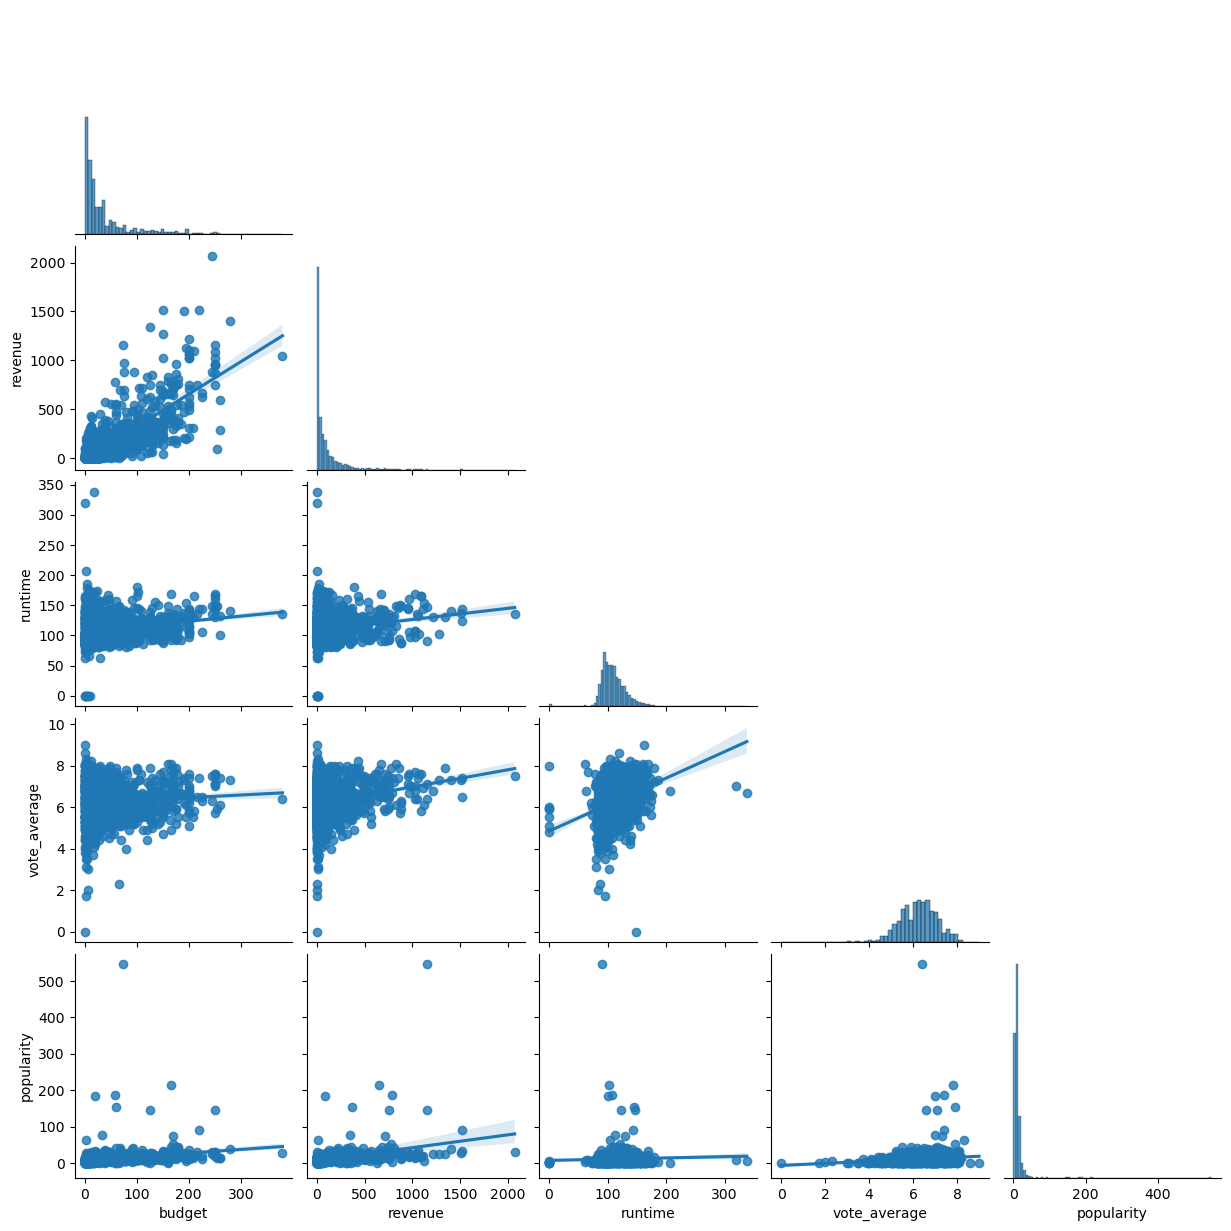

In [25]:
sns.pairplot(df, kind = "reg" , corner = True)
plt.show()

### Multiple Regression Analysis with statsmodels

In [30]:
df

,budget,revenue,runtime,vote_average,popularity
title,,,,,
Ca$h,7.0,0.046488,108.0,6.0,9.107829
Leap Year,19.0,29.922472,100.0,6.5,7.432311
Morning Glory,40.0,58.785180,102.0,6.1,10.771255
Devil,10.0,33.583175,80.0,5.8,7.094276
Tooth Fairy,48.0,112.462508,101.0,5.2,6.744680
...,...,...,...,...,...
Resident Evil: The Final Chapter,40.0,312.242626,107.0,5.9,0.755710
Railroad Tigers,50.0,102.205175,124.0,6.2,3.798504
Dangal,10.4,310.000000,161.0,8.0,8.792104


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1569 entries, Ca$h to 20th Century Women
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        1569 non-null   float64
 1   revenue       1569 non-null   float64
 2   runtime       1569 non-null   float64
 3   vote_average  1569 non-null   float64
 4   popularity    1569 non-null   float64
dtypes: float64(5)
memory usage: 105.8+ KB


In [32]:
from statsmodels.formula.api import ols

In [33]:
model = ols("revenue ~ budget + runtime + vote_average + popularity", data = df)

In [34]:
results = model.fit()

In [35]:
results.params

Intercept      -202.885651
budget            3.083032
runtime          -0.117440
vote_average     30.711734
popularity        2.059151
dtype: float64

In [36]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     847.8
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        14:54:50   Log-Likelihood:                -9703.0
No. Observations:                1569   AIC:                         1.942e+04
Df Residuals:                    1564   BIC:                         1.944e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -202.8857     23.469     -8.645   

In [37]:
results.predict()

array([  9.03687126,  58.87850165, 117.97799931, ...,  74.06821345,
       346.41242563,  49.2107336 ], shape=(1569,))

In [45]:
df = df.reindex(columns = ["revenue" , "budget", "predict", "runtime", "vote_average"])
df

,revenue,budget,predict,runtime,vote_average
title,,,,,
Ca$h,0.046488,7.0,NaN,108.0,6.0
Leap Year,29.922472,19.0,NaN,100.0,6.5
Morning Glory,58.785180,40.0,NaN,102.0,6.1
Devil,33.583175,10.0,NaN,80.0,5.8
Tooth Fairy,112.462508,48.0,NaN,101.0,5.2
...,...,...,...,...,...
Resident Evil: The Final Chapter,312.242626,40.0,NaN,107.0,5.9
Railroad Tigers,102.205175,50.0,NaN,124.0,6.2
Dangal,310.000000,10.4,NaN,161.0,8.0


In [52]:
df

,revenue,budget,runtime,vote_average
title,,,,
Ca$h,0.046488,7.0,108.0,6.0
Leap Year,29.922472,19.0,100.0,6.5
Morning Glory,58.785180,40.0,102.0,6.1
Devil,33.583175,10.0,80.0,5.8
Tooth Fairy,112.462508,48.0,101.0,5.2
...,...,...,...,...
Resident Evil: The Final Chapter,312.242626,40.0,107.0,5.9
Railroad Tigers,102.205175,50.0,124.0,6.2
Dangal,310.000000,10.4,161.0,8.0


In [53]:
df.insert(loc = 0, column = "revenue_pred", value = results.predict())

In [54]:
df

,revenue_pred,revenue,budget,runtime,vote_average
title,,,,,
Ca$h,9.036871,0.046488,7.0,108.0,6.0
Leap Year,58.878502,29.922472,19.0,100.0,6.5
Morning Glory,117.977999,58.785180,40.0,102.0,6.1
Devil,11.285727,33.583175,10.0,80.0,5.8
Tooth Fairy,106.827813,112.462508,48.0,101.0,5.2
...,...,...,...,...,...
Resident Evil: The Final Chapter,90.624936,312.242626,40.0,107.0,5.9
Railroad Tigers,134.937875,102.205175,50.0,124.0,6.2
Dangal,74.068213,310.000000,10.4,161.0,8.0


In [55]:
df.revenue - df.revenue_pred

title
Ca$h                                 -8.990383
Leap Year                           -28.956030
Morning Glory                       -59.192819
Devil                                22.297448
Tooth Fairy                           5.634695
                                       ...    
Resident Evil: The Final Chapter    221.617690
Railroad Tigers                     -32.732700
Dangal                              235.931787
Live by Night                      -323.733871
20th Century Women                  -43.394523
Length: 1569, dtype: float64

In [56]:
results.resid

title
Ca$h                                 -8.990383
Leap Year                           -28.956030
Morning Glory                       -59.192819
Devil                                22.297448
Tooth Fairy                           5.634695
                                       ...    
Resident Evil: The Final Chapter    221.617690
Railroad Tigers                     -32.732700
Dangal                              235.931787
Live by Night                      -323.733871
20th Century Women                  -43.394523
Length: 1569, dtype: float64

In [57]:
df = df.sort_values("revenue").reset_index()
df

,title,revenue_pred,revenue,budget,runtime,vote_average
0,The Letters,-39.675047,0.000001,0.000001,114.0,5.6
1,All at Once,-15.887888,0.000003,0.750000,0.0,6.0
2,Duniyadari,-219.030963,0.000003,0.390000,148.0,0.0
3,Raja Natwarlal,-48.245394,0.000004,0.000005,141.0,5.5
4,Bodyguard,-53.505265,0.000008,0.000130,130.0,5.2
...,...,...,...,...,...,...
1564,Avengers: Age of Ultron,944.969940,1405.403694,280.000000,141.0,7.3
1565,Furious 7,647.161668,1506.249360,190.000000,137.0,7.3
1566,Jurassic World,512.153481,1513.528810,150.000000,124.0,6.5
1567,The Avengers,870.946647,1519.557910,220.000000,143.0,7.4


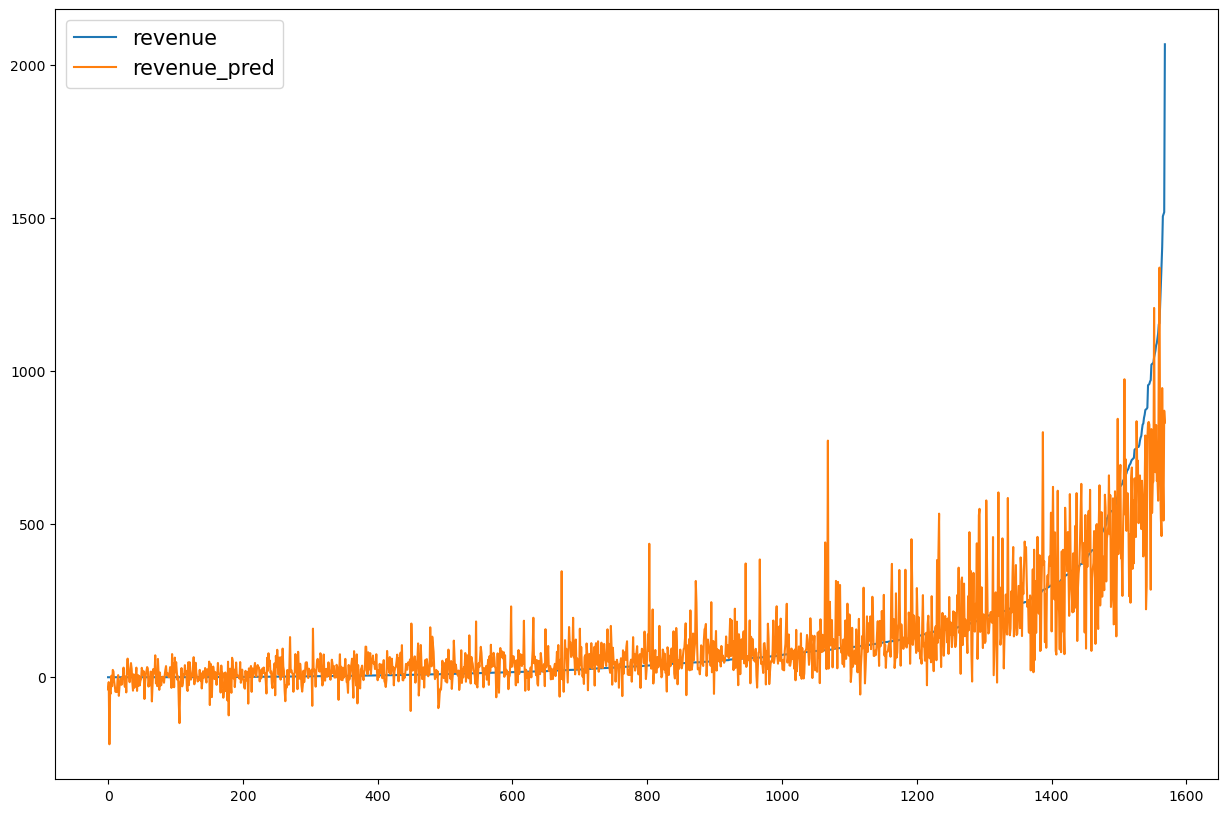

In [58]:
df.loc[:, ["revenue", "revenue_pred"]].plot(figsize = (15, 10))
plt.legend(fontsize = 15)
plt.show()

In [59]:
results.ssr

np.float64(21611479.34815669)

In [60]:
results.mse_resid

np.float64(13818.081424652615)

In [61]:
results.mse_resid**0.5

np.float64(117.5503357062523)

### Coefficient of Determination: the Adjusted R squared

Adjusted $R^2$ It penalizes adding unnecessary variables by accounting for:

* Number of predictors (features)
* Sample size
* Formula:

$$
\text{Ajusted  $R^2$}  = 1 - \Big(\frac{(1-R^2)\times (n-1)}{(n-p-1)}\Big)
$$

where 
* n = number of observations
* p = number of predictors (independent variables)


If Ajusted $R^2$ increases $\to$  $\color{#00FF00}{\text{: Keep the feature}}$ <br>
If Ajusted $R^2$ deccreases $\to$ $\color{#FF0000}{\text{: Remove the feature}}$

In [64]:
results.rsquared

np.float64(0.6843660611789255)

In [65]:
results.rsquared_adj

np.float64(0.683558813253552)

### Regression Coefficients, Hypothesis Testing & Model Specification

In [66]:
pd.options.display.float_format = '{:.4f}'.format

In [67]:
df

,title,revenue_pred,revenue,budget,runtime,vote_average
0,The Letters,-39.6750,0.0000,0.0000,114.0000,5.6000
1,All at Once,-15.8879,0.0000,0.7500,0.0000,6.0000
2,Duniyadari,-219.0310,0.0000,0.3900,148.0000,0.0000
3,Raja Natwarlal,-48.2454,0.0000,0.0000,141.0000,5.5000
4,Bodyguard,-53.5053,0.0000,0.0001,130.0000,5.2000
...,...,...,...,...,...,...
1564,Avengers: Age of Ultron,944.9699,1405.4037,280.0000,141.0000,7.3000
1565,Furious 7,647.1617,1506.2494,190.0000,137.0000,7.3000
1566,Jurassic World,512.1535,1513.5288,150.0000,124.0000,6.5000
1567,The Avengers,870.9466,1519.5579,220.0000,143.0000,7.4000


In [68]:
results.params

Intercept      -202.8857
budget            3.0830
runtime          -0.1174
vote_average     30.7117
popularity        2.0592
dtype: float64

In [69]:
results.tvalues

Intercept      -8.6450
budget         49.1353
runtime        -0.7983
vote_average    8.3246
popularity     12.2409
dtype: float64

In [70]:
results.pvalues

Intercept      0.0000
budget         0.0000
runtime        0.4248
vote_average   0.0000
popularity     0.0000
dtype: float64

In [71]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.684
Model:                            OLS   Adj. R-squared:                  0.684
Method:                 Least Squares   F-statistic:                     847.8
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:36:05   Log-Likelihood:                -9703.0
No. Observations:                1569   AIC:                         1.942e+04
Df Residuals:                    1564   BIC:                         1.944e+04
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -202.8857     23.469     -8.645   

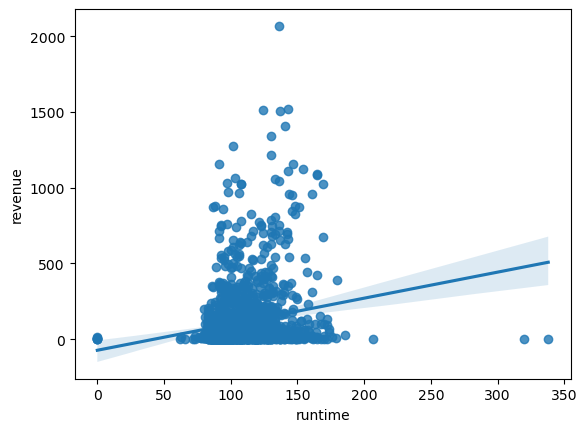

In [74]:
sns.regplot(x = "runtime", y = "revenue", data = df)
plt.show()

The slope of the regression line is positive, but we need to prove it:

In [86]:
# model: revenue vs runtime:
model_runtime = ols("revenue ~ runtime", data = df)
results_runtime = model_runtime.fit()
print(results_runtime.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.032
Model:                            OLS   Adj. R-squared:                  0.031
Method:                 Least Squares   F-statistic:                     51.62
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           1.04e-12
Time:                        16:50:43   Log-Likelihood:                -10582.
No. Observations:                1569   AIC:                         2.117e+04
Df Residuals:                    1567   BIC:                         2.118e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -73.5457     26.840     -2.740      0.0

In [87]:
results_runtime.params

Intercept   -73.5457
runtime       1.7194
dtype: float64

We can see the the slope of runtime is  1.7194 >0

Now let's see the relationship between the budget and the runtime:

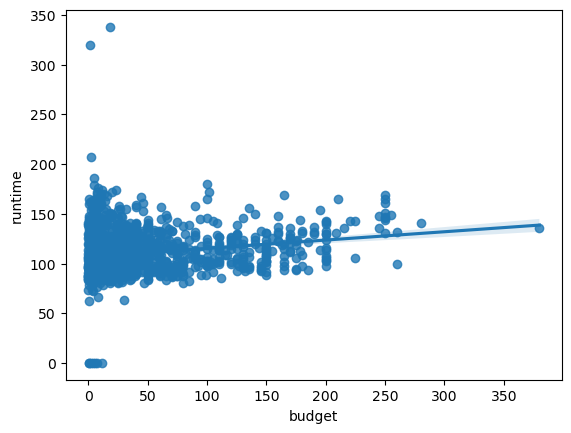

In [75]:
sns.regplot(x = "budget", y = "runtime", data = df)
plt.show()

In [88]:
model_budget = ols("runtime ~ budget", data = df)
results_budget = model_budget.fit()
print(results_budget.summary())


                            OLS Regression Results                            
Dep. Variable:                runtime   R-squared:                       0.037
Model:                            OLS   Adj. R-squared:                  0.037
Method:                 Least Squares   F-statistic:                     60.69
Date:                Mon, 22 Jun 2026   Prob (F-statistic):           1.21e-14
Time:                        16:52:40   Log-Likelihood:                -7024.5
No. Observations:                1569   AIC:                         1.405e+04
Df Residuals:                    1567   BIC:                         1.406e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    106.8603      0.674    158.466      0.0

In [78]:
df

,title,revenue_pred,revenue,budget,runtime,vote_average
0,The Letters,-39.6750,0.0000,0.0000,114.0000,5.6000
1,All at Once,-15.8879,0.0000,0.7500,0.0000,6.0000
2,Duniyadari,-219.0310,0.0000,0.3900,148.0000,0.0000
3,Raja Natwarlal,-48.2454,0.0000,0.0000,141.0000,5.5000
4,Bodyguard,-53.5053,0.0000,0.0001,130.0000,5.2000
...,...,...,...,...,...,...
1564,Avengers: Age of Ultron,944.9699,1405.4037,280.0000,141.0000,7.3000
1565,Furious 7,647.1617,1506.2494,190.0000,137.0000,7.3000
1566,Jurassic World,512.1535,1513.5288,150.0000,124.0000,6.5000
1567,The Avengers,870.9466,1519.5579,220.0000,143.0000,7.4000


In [92]:
model = ols("revenue ~  budget + runtime + vote_average", data = df)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     986.6
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:59:16   Log-Likelihood:                -9774.8
No. Observations:                1569   AIC:                         1.956e+04
Df Residuals:                    1565   BIC:                         1.958e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -212.5951     24.545     -8.661   

In [84]:
results = model.fit()

In [85]:
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                revenue   R-squared:                       0.654
Model:                            OLS   Adj. R-squared:                  0.653
Method:                 Least Squares   F-statistic:                     986.6
Date:                Mon, 22 Jun 2026   Prob (F-statistic):               0.00
Time:                        16:49:04   Log-Likelihood:                -9774.8
No. Observations:                1569   AIC:                         1.956e+04
Df Residuals:                    1565   BIC:                         1.958e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     -212.5951     24.545     -8.661   

### The F-Test

In [ ]:
results.fvalue

In [ ]:
results.f_pvalue

In [ ]:
print(results.summary())

### Creating and working with Dummy Variables (Part 1)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
movie = pd.read_csv("movies_metadata.csv", low_memory= False)

In [ ]:
movie = movie.set_index(pd.to_datetime(movie.release_date, errors = "coerce")).drop(columns = ["release_date"])

In [ ]:
movie.sort_index(inplace = True)

In [ ]:
# Remove rows with NaT in the index
movie = movie[~movie.index.isna()]
movie

In [ ]:
movie

In [ ]:
df = movie.loc["2010":"2016", ["title", "budget", "revenue", "vote_average", "popularity",
                              "belongs_to_collection", "original_language"]].copy()

In [ ]:
df.budget = pd.to_numeric(df.budget, errors = "coerce")

In [ ]:
df.popularity = pd.to_numeric(df.popularity, errors = "coerce")

In [ ]:
df = df[(df.revenue > 0) & (df.budget > 0)]

In [ ]:
df.loc[:, ["budget", "revenue"]] = df.loc[:, ["budget", "revenue"]] / 1000000

In [ ]:
df.sort_values("revenue", ascending = False)

In [ ]:
df.belongs_to_collection.notnull()

In [ ]:
df.belongs_to_collection = df.belongs_to_collection.notnull()

In [ ]:
df.set_index("title", inplace = True)

In [ ]:
df

In [ ]:
plt.figure(figsize = (12,8))
sns.set(font_scale=1.5)
sns.regplot(x = "belongs_to_collection", y = "revenue", data = df)
plt.show()

In [ ]:
from statsmodels.formula.api import ols

In [ ]:
model = ols("revenue ~ budget + popularity + vote_average + belongs_to_collection", data = df)

In [ ]:
results = model.fit()

In [ ]:
print(results.summary())

### Creating and working with Dummy Variables (Part 2)

In [ ]:
df

In [ ]:
df.original_language.nunique()

In [ ]:
df.original_language.value_counts()

In [ ]:
df_dumm = pd.get_dummies(df, columns = ["original_language"])

In [ ]:
df_dumm

In [ ]:
df_dumm.columns.str.contains("language").sum()

In [ ]:
plt.figure(figsize = (12,8))
sns.set(font_scale=1.5)
sns.regplot(x = "original_language_en", y = "revenue", data = df_dumm)
plt.show()

In [ ]:
model = ols("revenue ~ original_language_en", data = df_dumm)

In [ ]:
results = model.fit()

In [ ]:
print(results.summary())

In [ ]:
model = ols("revenue ~ budget + popularity + vote_average + belongs_to_collection", data = df_dumm)

In [ ]:
results = model.fit()

In [ ]:
print(results.summary())